In [23]:
import warnings
warnings.filterwarnings('ignore')  

import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE, Isomap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
import umap

# 设置随机种子
np.random.seed(42)

In [6]:
# ==================== 1. 数据加载与预处理（改用 TensorFlow 内置） ====================
print("Loading Fashion-MNIST dataset via TensorFlow...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 合并训练集和测试集（共 70000 张）
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# 展平 28x28 -> 784 维向量，并归一化到 [0,1]
X = X.reshape(X.shape[0], -1).astype(np.float32) / 255.0
y = y.astype(np.int32)

# 随机抽取 5000 个样本（保证实验速度，同时保持代表性）
n_samples = 5000
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X_sub = X[indices]
y_sub = y[indices]

# 标准化（对 PCA、MDA、KPCA 等线性/核方法有益）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

print(f"数据形状: {X_scaled.shape}, 类别数: {len(np.unique(y_sub))}")

Loading Fashion-MNIST dataset via TensorFlow...
数据形状: (5000, 784), 类别数: 10


In [24]:
# ==================== 2. 配置降维方法 ====================
methods = {
    'PCA': PCA(n_components=2, random_state=42),
    'MDA': LDA(n_components=2),
    'KPCA': KernelPCA(n_components=2, kernel='rbf', gamma=0.001, random_state=42),
    'ISOMAP': Isomap(n_components=2, n_neighbors=15),
    't-SNE': TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500),
    'UMAP': umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.3,  n_epochs=300,random_state=42)
}

In [25]:
# ==================== 3. 执行降维 ====================
results = {}
times = {}

for name, method in methods.items():
    print(f"\n正在处理 {name}...")
    start = time.time()
    if name == 'MDA':
        X_trans = method.fit_transform(X_scaled, y_sub)
    elif name in ['PCA', 'KPCA']:
        X_trans = method.fit_transform(X_scaled)
    else:
        X_trans = method.fit_transform(X_sub)   # ISOMAP/t-SNE/UMAP 直接使用原始数据（无需标准化）
    times[name] = time.time() - start
    results[name] = X_trans
    print(f"{name} 完成，耗时 {times[name]:.2f} 秒")


正在处理 PCA...
PCA 完成，耗时 0.08 秒

正在处理 MDA...
MDA 完成，耗时 0.86 秒

正在处理 KPCA...
KPCA 完成，耗时 0.90 秒

正在处理 ISOMAP...
ISOMAP 完成，耗时 19.71 秒

正在处理 t-SNE...
t-SNE 完成，耗时 13.37 秒

正在处理 UMAP...
UMAP 完成，耗时 6.38 秒


In [26]:
import matplotlib.pyplot as plt

# 设置中文字体（黑体，常见于 Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']   # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False     # 解决负号 '-' 显示为方块的问题

单独图片已保存


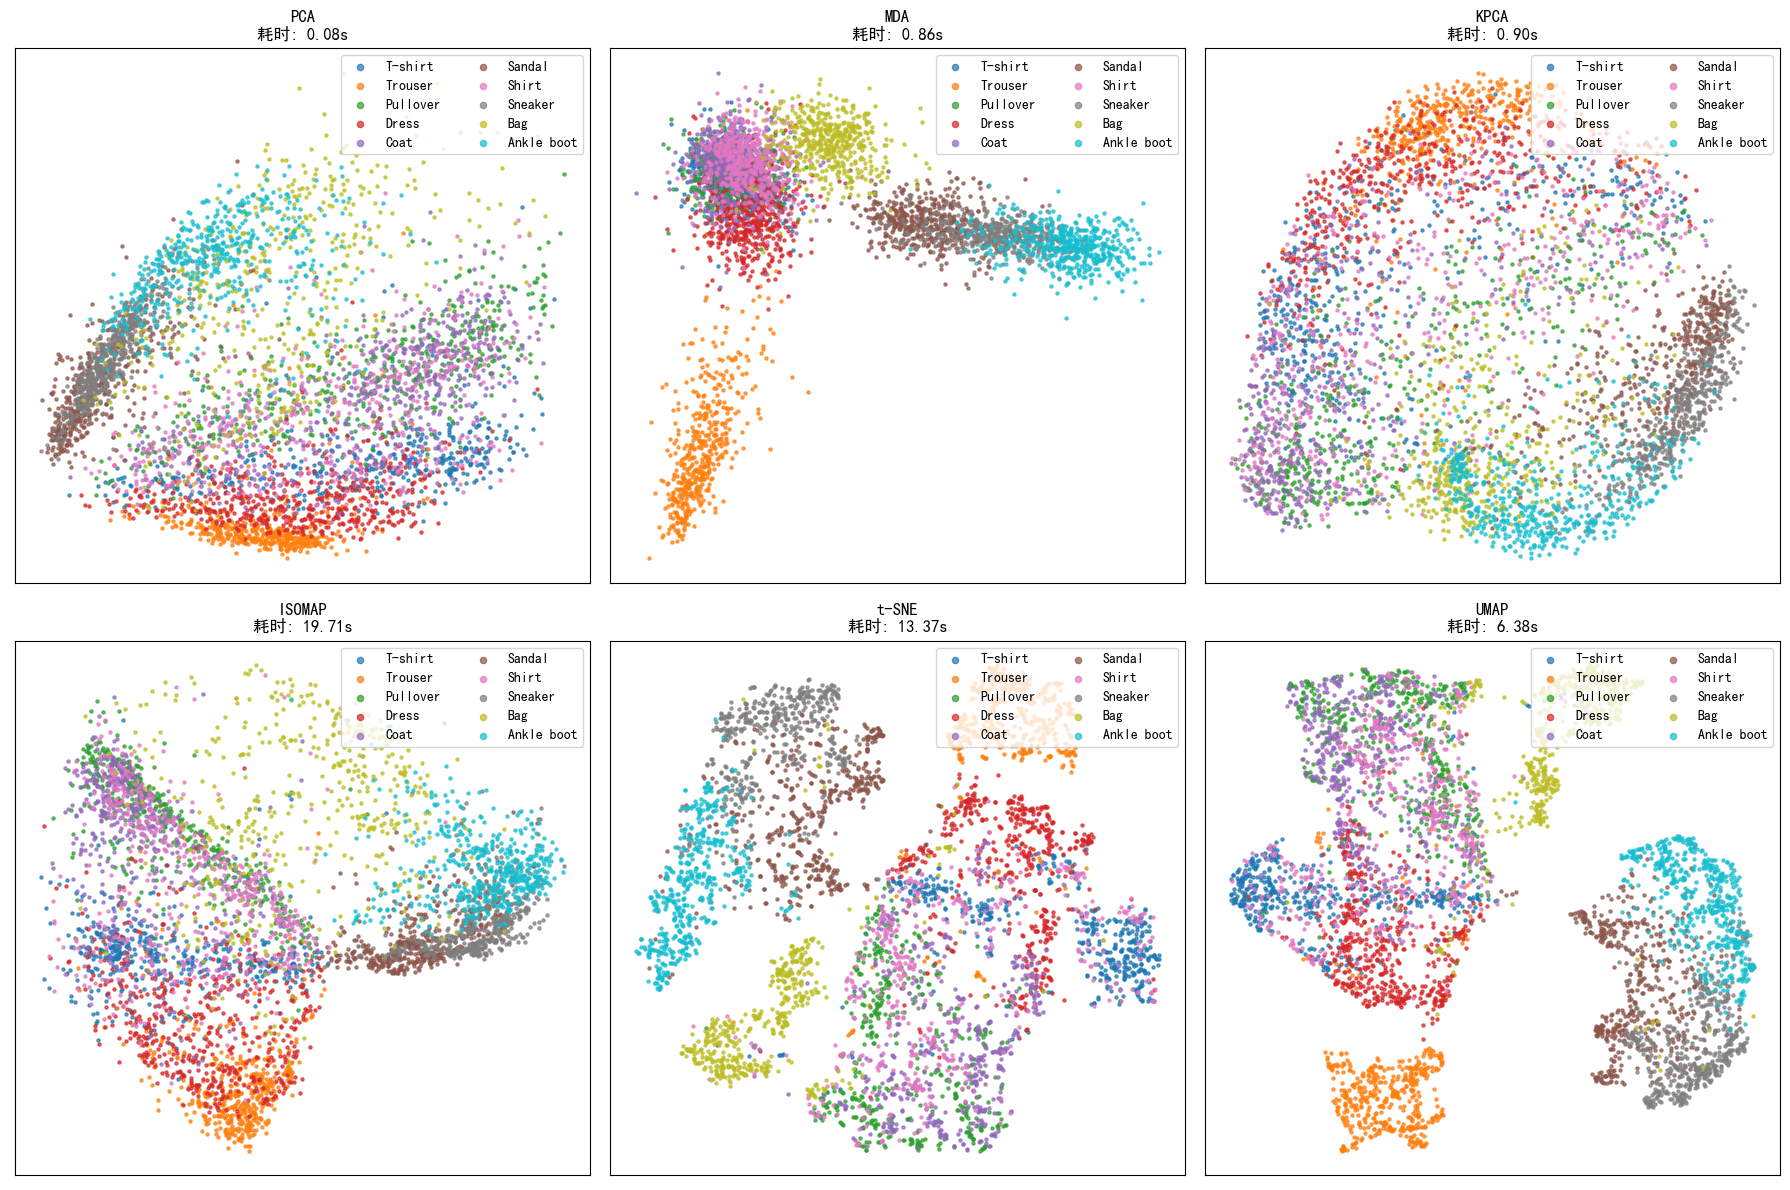

In [37]:
# ==================== 4. 可视化（分别保存每个算法的散点图 + 整体子图） ====================
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# ---- 第一部分：分别保存每个算法的单独图片 ----
for name, X_trans in results.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    for c in range(10):
        mask = y_sub == c
        ax.scatter(X_trans[mask, 0], X_trans[mask, 1], 
                   c=[colors[c]], label=class_names[c], s=5, alpha=0.7)
    ax.set_title(f'{name}\n耗时: {times[name]:.2f}s', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=10, ncol=2, markerscale=2.0)
    plt.tight_layout()
    plt.savefig(f'{name}_fashion_mnist.png', dpi=150, bbox_inches='tight')
    plt.close()  # 关闭图形，释放内存

print("单独图片已保存")

# ---- 第二部分：创建整体子----
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, X_trans) in enumerate(results.items()):
    ax = axes[idx]
    for c in range(10):
        mask = y_sub == c
        ax.scatter(X_trans[mask, 0], X_trans[mask, 1], 
                   c=[colors[c]], label=class_names[c], s=5, alpha=0.7)
    ax.set_title(f'{name}\n耗时: {times[name]:.2f}s', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=10, ncol=2, markerscale=2.0)

plt.tight_layout()
plt.savefig('fashion_mnist_dr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ==================== 5. 定量评估 ====================
print("\n" + "="*60)
print("定量评估结果")
print("="*60)

print("\n【KNN分类准确率 (5折交叉验证, k=5)】")
for name, X_trans in results.items():
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X_trans, y_sub, cv=5, scoring='accuracy')
    print(f"{name:10s}: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n【轮廓系数 (Silhouette Score)】")
for name, X_trans in results.items():
    try:
        sc = silhouette_score(X_trans, y_sub)
        print(f"{name:10s}: {sc:.4f}")
    except:
        print(f"{name:10s}: N/A")



定量评估结果

【KNN分类准确率 (5折交叉验证, k=5)】
PCA       : 0.4956 ± 0.0110
MDA       : 0.5668 ± 0.0089
KPCA      : 0.4884 ± 0.0087
ISOMAP    : 0.5698 ± 0.0100
t-SNE     : 0.7910 ± 0.0078
UMAP      : 0.7460 ± 0.0065

【轮廓系数 (Silhouette Score)】
PCA       : -0.0421
MDA       : 0.1571
KPCA      : -0.0455
ISOMAP    : 0.0230
t-SNE     : 0.1486
UMAP      : 0.1686
